**DL_PA2   Roll_Number 25280103:     In this we have to check the model accurac by using the different optimization and genalization techniques: And try to increase the model accuracy by using different methods and techniques**

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [35]:
##Loading the data
train_data = np.load("processed_data/quickdraw_train.npz")
test_data = np.load("processed_data/quickdraw_test.npz")

print("Train keys:", train_data.files)
print("Test keys:", test_data.files)

Train keys: ['x_train', 'y_train', 'class_names']
Test keys: ['test_images']


In [36]:
#extract Arrays
# Extract arrays correctly

X_train = train_data['x_train']
y_train = train_data['y_train']
class_names = train_data['class_names']

X_test = test_data['test_images']

print("Train shape:", X_train.shape)
print("Labels shape:", y_train.shape)
print("Test shape:", X_test.shape)
print("Number of classes:", len(class_names))

Train shape: (60000, 784)
Labels shape: (60000,)
Test shape: (15000, 784)
Number of classes: 15


In [37]:
#preprocessing the data for training and testing
# Normalize pixel values to [0,1]

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Min value:", X_train.min())
print("Max value:", X_train.max())

Min value: 0.0
Max value: 1.0


In [38]:
# Convert to PyTorch tensors

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)

print("Tensor shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)

Using device: cpu
Tensor shapes:
X_train: torch.Size([60000, 784])
y_train: torch.Size([60000])
X_test: torch.Size([15000, 784])


In [39]:
#this was giving the 77 to 80% accuracy, now i will use the augmentation to see if it can improve the accuracy
import torchvision.transforms as transforms

# Define augmentation
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor()
])

In [40]:
from torch.utils.data import Dataset

class AugmentedDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx].reshape(28, 28)
        label = self.y[idx]

        if self.augment:
            image = transform(image.numpy().astype('float32'))
            image = image.view(-1)
        else:
            image = torch.tensor(image, dtype=torch.float32).view(-1)

        return image, label

In [41]:
train_dataset = AugmentedDataset(X_train, y_train, augment=True)
val_dataset = AugmentedDataset(X_train[48000:], y_train[48000:], augment=False)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256)

""Part 1 Pencake Wise Model where we used the multiple neurons but less number of hidden layers""

In [42]:
# PART A — Pancake Model (Wide, Shallow)

class PancakeMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 15)
        )

    def forward(self, x):
        return self.model(x)

pancake = PancakeMLP().to(device)

# Count parameters
total_params = sum(p.numel() for p in pancake.parameters())
print("Pancake parameter count:", total_params)

Pancake parameter count: 1868815


**Model Tranining**
Training Function in which use different types of optimizers and also the lr: 
First used the lr=0.001 and weight decay: 1e-4;    and 35 epchos optimizer used the adam:   
It gave the accuracy 79% and but traning 99 percentage: 

**Model Traning second time and Function**
Decrease the learning rate to 0.0007: increse the capacity:    and weight decay kept same: epochos same:    And used the schedulere optimizer:   same used the batch normalization and also the Gel function and dropout from 0.25 to 0.35: but it gave the accuracy slightly increase to 80% 

**Model Traning 3rd time and optimizations**
Learning rate more decrese used the 0.0005: But still it gave the 80% and used the weight_decay of 5e-4: And epchos 38: In this time i observe that traning increased slowly and also the val increse with it but training went to 99% but the val still quite on the 80%: now im thinking that i should add the regularization and also this time i decreased the data but still it gave the same accuracy: And i also thinking that i should change the optimization techinque this time...

**Model Traning and optimization 4rth time**
This time used the 40 epochs and also use the lr=0.05 and also used the 1million 65k parameters: 

**Model Traning and Optimization 4rth time B**
I minimized the learning rate to 0.0005 in the start it gave the best but after that it still showed 77% result accuracy:

**Model Traning and Optimiztion 5th time**
This time i used the augumentation for data set this gives me the underfitting and also it gave me the highest accuracy 88% and mostly more than the 80% and also used the same relu function drop affect and also the batch optimization technique: And parameters used 0.8 million and something


In [43]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_model(model, epochs=35):

    optimizer = optim.AdamW(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_val_acc = 0.0

    train_acc_list = []
    val_acc_list = []

    for epoch in range(epochs):

        # ---------------- TRAIN ----------------
        model.train()
        correct = 0
        total = 0
        running_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()

            outputs = model(xb)
            loss = criterion(outputs, yb)

            loss.backward()

            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        train_acc = correct / total

        # ---------------- VALIDATION ----------------
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)

                outputs = model(xb)
                preds = torch.argmax(outputs, dim=1)

                correct += (preds == yb).sum().item()
                total += yb.size(0)

        val_acc = correct / total

        scheduler.step()

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")

        print(f"Epoch {epoch+1:02d} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Val Acc: {val_acc:.4f} | "
              f"Best: {best_val_acc:.4f}")

    print("\nTraining Complete.")
    print("Best Validation Accuracy:", best_val_acc)

    return train_acc_list, val_acc_list

In [44]:
print("Training Pancake Model...")

# p_train, p_val = train_model(pancake, epochs=35)        
train_model(pancake, epochs=30)                                                                                                        

Training Pancake Model...


C:\Users\Teacher\AppData\Local\Temp\ipykernel_30588\2967252158.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32).view(-1)


Epoch 01 | Train Acc: 0.5412 | Val Acc: 0.7958 | Best: 0.7958
Epoch 02 | Train Acc: 0.6713 | Val Acc: 0.8164 | Best: 0.8164
Epoch 03 | Train Acc: 0.7044 | Val Acc: 0.8145 | Best: 0.8164
Epoch 04 | Train Acc: 0.7271 | Val Acc: 0.8178 | Best: 0.8178
Epoch 05 | Train Acc: 0.7405 | Val Acc: 0.8875 | Best: 0.8875
Epoch 06 | Train Acc: 0.7536 | Val Acc: 0.8613 | Best: 0.8875
Epoch 07 | Train Acc: 0.7636 | Val Acc: 0.8548 | Best: 0.8875
Epoch 08 | Train Acc: 0.7735 | Val Acc: 0.8406 | Best: 0.8875
Epoch 09 | Train Acc: 0.7795 | Val Acc: 0.8697 | Best: 0.8875
Epoch 10 | Train Acc: 0.7854 | Val Acc: 0.8253 | Best: 0.8875
Epoch 11 | Train Acc: 0.7910 | Val Acc: 0.8598 | Best: 0.8875
Epoch 12 | Train Acc: 0.7959 | Val Acc: 0.8598 | Best: 0.8875
Epoch 13 | Train Acc: 0.8004 | Val Acc: 0.8798 | Best: 0.8875
Epoch 14 | Train Acc: 0.8064 | Val Acc: 0.8449 | Best: 0.8875
Epoch 15 | Train Acc: 0.8108 | Val Acc: 0.8641 | Best: 0.8875
Epoch 16 | Train Acc: 0.8148 | Val Acc: 0.8601 | Best: 0.8875
Epoch 17

([0.5412166666666667,
  0.6712833333333333,
  0.70435,
  0.7271333333333333,
  0.7405333333333334,
  0.7536,
  0.7636166666666667,
  0.7735333333333333,
  0.7794666666666666,
  0.7853666666666667,
  0.7910333333333334,
  0.7959333333333334,
  0.8004,
  0.8064,
  0.8108166666666666,
  0.8147833333333333,
  0.8183333333333334,
  0.82265,
  0.8248,
  0.8295,
  0.83385,
  0.83465,
  0.8389,
  0.8398833333333333,
  0.8414833333333334,
  0.8449833333333333,
  0.8443666666666667,
  0.8447166666666667,
  0.8456833333333333,
  0.8451666666666666],
 [0.7958333333333333,
  0.8164166666666667,
  0.8145,
  0.8178333333333333,
  0.8875,
  0.8613333333333333,
  0.85475,
  0.8405833333333333,
  0.8696666666666667,
  0.82525,
  0.8598333333333333,
  0.85975,
  0.87975,
  0.8449166666666666,
  0.8640833333333333,
  0.8600833333333333,
  0.9061666666666667,
  0.8823333333333333,
  0.8943333333333333,
  0.8911666666666667,
  0.91375,
  0.9039166666666667,
  0.901,
  0.8974166666666666,
  0.891583333333333

**As we used the higher number of so features are memorised by the neurons and in this pancake as multiple nodes used so its giving the less accuracy than the training model sever overfitting....**

**2nd Tower model in this we use the multiple hidden layers and not much the neurons... that's why its called the tower model...**

In [45]:
# PART B — Tower Model (Deep & Narrow)

class TowerMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 15)
        )

    def forward(self, x):
        return self.model(x)

tower = TowerMLP().to(device)

print("Tower parameter count:", sum(p.numel() for p in tower.parameters()))

Tower parameter count: 470543


In [46]:
#train Tower model
print("Training Tower Model...")

# t_train, t_val = train_model(tower, epochs=35)
train_model(tower, epochs=30)


Training Tower Model...


C:\Users\Teacher\AppData\Local\Temp\ipykernel_30588\2967252158.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32).view(-1)


Epoch 01 | Train Acc: 0.5857 | Val Acc: 0.7153 | Best: 0.7153
Epoch 02 | Train Acc: 0.6781 | Val Acc: 0.7997 | Best: 0.7997
Epoch 03 | Train Acc: 0.7040 | Val Acc: 0.7942 | Best: 0.7997
Epoch 04 | Train Acc: 0.7244 | Val Acc: 0.8164 | Best: 0.8164
Epoch 05 | Train Acc: 0.7355 | Val Acc: 0.8054 | Best: 0.8164
Epoch 06 | Train Acc: 0.7477 | Val Acc: 0.8167 | Best: 0.8167
Epoch 07 | Train Acc: 0.7545 | Val Acc: 0.8142 | Best: 0.8167
Epoch 08 | Train Acc: 0.7627 | Val Acc: 0.8333 | Best: 0.8333
Epoch 09 | Train Acc: 0.7689 | Val Acc: 0.8517 | Best: 0.8517
Epoch 10 | Train Acc: 0.7746 | Val Acc: 0.8491 | Best: 0.8517
Epoch 11 | Train Acc: 0.7798 | Val Acc: 0.8304 | Best: 0.8517
Epoch 12 | Train Acc: 0.7838 | Val Acc: 0.8493 | Best: 0.8517
Epoch 13 | Train Acc: 0.7889 | Val Acc: 0.8003 | Best: 0.8517
Epoch 14 | Train Acc: 0.7945 | Val Acc: 0.8468 | Best: 0.8517
Epoch 15 | Train Acc: 0.7946 | Val Acc: 0.8748 | Best: 0.8748
Epoch 16 | Train Acc: 0.7997 | Val Acc: 0.8854 | Best: 0.8854
Epoch 17

([0.5856666666666667,
  0.6781,
  0.704,
  0.7243833333333334,
  0.73545,
  0.7476833333333334,
  0.7544666666666666,
  0.7627166666666667,
  0.7689166666666667,
  0.77465,
  0.7798333333333334,
  0.7837833333333334,
  0.7888833333333334,
  0.7944833333333333,
  0.7946333333333333,
  0.7996666666666666,
  0.8058,
  0.8076833333333333,
  0.81065,
  0.8147,
  0.81775,
  0.8192,
  0.8221666666666667,
  0.8232833333333334,
  0.8256333333333333,
  0.8266666666666667,
  0.8304166666666667,
  0.8311,
  0.8315666666666667,
  0.831],
 [0.71525,
  0.7996666666666666,
  0.7941666666666667,
  0.8164166666666667,
  0.8054166666666667,
  0.81675,
  0.8141666666666667,
  0.8333333333333334,
  0.8516666666666667,
  0.8490833333333333,
  0.8304166666666667,
  0.8493333333333334,
  0.8003333333333333,
  0.84675,
  0.8748333333333334,
  0.8854166666666666,
  0.8659166666666667,
  0.8714166666666666,
  0.8855833333333333,
  0.879,
  0.86475,
  0.8720833333333333,
  0.886,
  0.8725833333333334,
  0.8888333

**For the first championFunction used the linear, optiomizaiton BatchnNorm1d, Gelu activation function and also used the dropout 0.3 and data 1.9 nodes: it gave the accuracy of 99% for the test but 79% for the validation:**

In [47]:
import torch
import torch.nn as nn

class ChampionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.20),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(128, 15)
        )

    def forward(self, x):
        return self.model(x)

champion = ChampionMLP().to(device)

print("Champion parameter count:",
      sum(p.numel() for p in champion.parameters()))

Champion parameter count: 569871


In [48]:
champion = ChampionMLP().to(device)

print("Training Champion Model...")

c_train, c_val = train_model(champion, epochs=20)


Training Champion Model...


C:\Users\Teacher\AppData\Local\Temp\ipykernel_30588\2967252158.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32).view(-1)


Epoch 01 | Train Acc: 0.5458 | Val Acc: 0.8036 | Best: 0.8036
Epoch 02 | Train Acc: 0.6439 | Val Acc: 0.8203 | Best: 0.8203
Epoch 03 | Train Acc: 0.6708 | Val Acc: 0.8050 | Best: 0.8203
Epoch 04 | Train Acc: 0.6880 | Val Acc: 0.8369 | Best: 0.8369
Epoch 05 | Train Acc: 0.7016 | Val Acc: 0.8153 | Best: 0.8369
Epoch 06 | Train Acc: 0.7125 | Val Acc: 0.8231 | Best: 0.8369
Epoch 07 | Train Acc: 0.7224 | Val Acc: 0.8175 | Best: 0.8369
Epoch 08 | Train Acc: 0.7295 | Val Acc: 0.8512 | Best: 0.8512
Epoch 09 | Train Acc: 0.7360 | Val Acc: 0.8459 | Best: 0.8512
Epoch 10 | Train Acc: 0.7424 | Val Acc: 0.8416 | Best: 0.8512
Epoch 11 | Train Acc: 0.7499 | Val Acc: 0.8488 | Best: 0.8512
Epoch 12 | Train Acc: 0.7509 | Val Acc: 0.8468 | Best: 0.8512
Epoch 13 | Train Acc: 0.7562 | Val Acc: 0.8476 | Best: 0.8512
Epoch 14 | Train Acc: 0.7611 | Val Acc: 0.8325 | Best: 0.8512
Epoch 15 | Train Acc: 0.7609 | Val Acc: 0.8402 | Best: 0.8512
Epoch 16 | Train Acc: 0.7657 | Val Acc: 0.8379 | Best: 0.8512
Epoch 17

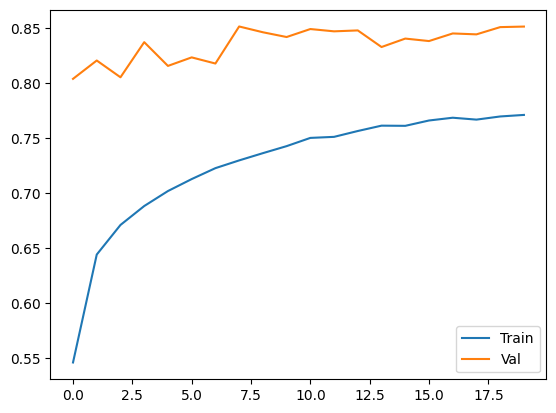

In [49]:
#Plot Curves
plt.plot(c_train, label="Train")
plt.plot(c_val, label="Val")
plt.legend()
plt.show()

C:\Users\Teacher\AppData\Local\Temp\ipykernel_30588\2967252158.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32).view(-1)


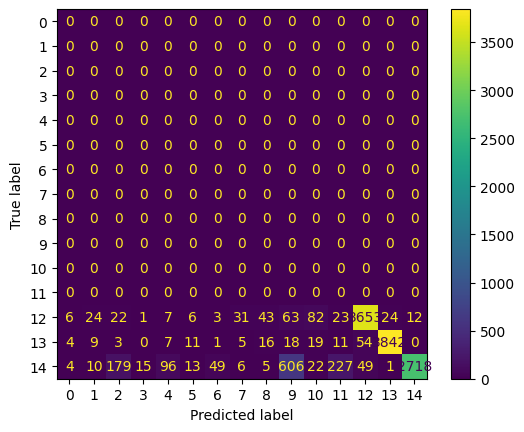

In [50]:
#Confusion Matrix
champion.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in val_loader:
        outputs = champion(xb)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [51]:
#save the bestModel
torch.save(champion.state_dict(), "best_model2.pth")

In [52]:
#Generate test prediction
champion.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    outputs = champion(X_test_tensor)
    preds = torch.argmax(outputs, dim=1)

np.savetxt("submission3.csv", preds.numpy(), fmt="%d", delimiter=",")

C:\Users\Teacher\AppData\Local\Temp\ipykernel_30588\459813696.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32)


In [53]:
import pandas as pd

df = pd.read_csv("submission3.csv", header=None)
preds = df[0].tolist()

print(",".join(map(str, preds)))

6,11,5,5,0,1,11,9,14,8,9,7,11,11,13,8,13,12,11,3,13,6,14,8,0,13,13,2,6,5,14,9,1,12,13,5,11,5,8,2,12,8,0,2,13,1,11,9,10,1,5,2,0,9,5,11,11,6,10,9,9,6,7,2,0,12,2,12,3,11,4,6,3,14,13,6,5,6,11,11,10,13,6,4,12,0,0,2,4,11,0,7,1,2,5,6,3,12,9,10,14,12,1,4,5,9,7,4,14,11,9,1,1,13,12,2,1,7,9,0,4,7,14,2,13,13,7,14,3,4,5,6,0,8,14,11,11,12,1,13,10,2,1,9,1,12,7,2,3,0,4,14,1,12,6,8,0,4,9,6,0,9,5,13,9,13,11,6,1,5,12,10,4,4,13,7,14,14,7,11,2,13,10,3,12,3,8,6,2,1,9,9,8,6,0,4,1,5,5,10,5,14,10,1,13,1,1,10,5,7,14,11,1,9,6,2,6,3,8,1,1,4,7,12,9,6,13,14,3,0,9,6,4,11,1,3,10,0,11,4,9,11,4,12,4,9,5,0,6,7,6,5,7,1,13,5,1,9,0,4,13,0,7,4,6,3,12,12,3,7,13,11,11,3,0,8,12,8,6,6,1,7,12,12,0,3,14,3,12,6,6,6,2,0,9,12,9,6,2,1,5,12,3,0,6,11,11,7,13,8,12,13,9,1,5,3,9,10,14,13,0,9,12,11,7,9,3,10,11,12,13,12,6,3,2,9,7,8,10,1,11,10,2,1,10,14,12,14,0,7,7,0,2,7,3,7,12,1,10,12,11,13,3,11,5,14,11,8,7,11,12,11,4,13,1,14,3,1,0,13,10,3,10,9,6,0,4,10,10,2,4,5,14,2,3,11,13,10,4,13,9,3,8,1,13,9,7,14,0,0,14,12,5,10,0,0,8,10,9,7,0,12,12,2,11